## Basic Setup

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization
from keras.models import Sequential, Model
from keras.optimizers import SGD
from keras.applications import MobileNetV2
from keras.regularizers import l2

os.chdir('../../../') # move three level up to the base path
from src.utils import load_and_preprocess_images, plot_images
from src.model_evaluation import evaluate_model, plot_history, plot_predictions

In [3]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [4]:
model_name = '1_synthetic_eyes'
transfer_learning_stage = '0_last_layers'
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'

syntheticDataPath = repo_path + '/data/Unity_Data_Test_Train'
syntheticTrainingPath = syntheticDataPath + '/TrainingSet'
syntheticTestPath = syntheticDataPath + '/TestSet'

In [5]:
comment = "afternoon run"
model_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/weights/{comment}_model.keras"
ckpt_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/ckpt/{comment}_checkpoint.model.keras"
history_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/history/{comment}_history.csv"
assert not os.path.exists(ckpt_file_path), "Model already exists. Please change the comment."

In [6]:
# Hyperparameters
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

MN_OUTPUT_LAYER = 'block_16_project_BN'
UNFREEZE_FROM_LAYER = 'block_16_project_BN'
DATA_AUG_RATE = 0.1
EPOCHS = 100
REGULARIZATION = 0.01
DROPOUT = 0.3
LEARNING_RATE = 0.0001
LOSS_FUNCTION = 'sparse_categorical_crossentropy'
OPTIMIZER = SGD(learning_rate=LEARNING_RATE)

In [10]:
early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=20, start_from_epoch=10)
checkpoint = ModelCheckpoint(ckpt_file_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=10, min_lr=0.00001, verbose=1)

In [8]:
synth_train_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
synth_valid_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
synth_test_data = load_and_preprocess_images(syntheticTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 4743 files belonging to 2 classes.
Using 3795 files for training.
Found 4743 files belonging to 2 classes.
Using 948 files for validation.
Found 1187 files belonging to 2 classes.


## Training the Pre-Trained Model

In [9]:
def initialize_baseline_model(title, mn_output_layer, unfreeze_from_layer, loss_function, optimizer, dropout_rate, regularization_rate, input_shape=INPUT_SHAPE):

    # Load the MobileNetV2 model    
    pretrained_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')

    pretrained_model.trainable = False

    # Unfreeze the layers starting from unfreeze_from_layer (exclusive)
    unfreeze = False
    for layer in pretrained_model.layers:
        if unfreeze:
            layer.trainable = True
        elif layer.name == unfreeze_from_layer:
            layer.trainable = False
            unfreeze = True

    # Ensure BN layers are in inference mode
    for layer in pretrained_model.layers:
        if isinstance(layer, BatchNormalization):
            layer.trainable = False
        
    # Get the desired output layer
    last_layer = pretrained_model.get_layer(mn_output_layer)
    base_model = Model(inputs=pretrained_model.input, outputs=last_layer.output)

    # Functional API model construction
    x = base_model.output
    x = Flatten()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(regularization_rate))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(regularization_rate))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(2, activation='softmax')(x)
    
    # Define the final model
    model = Model(inputs=base_model.input, outputs=outputs, name=title)

    # Compile the model
    model.compile(loss=loss_function, optimizer=optimizer, metrics=['accuracy'])

    return model

In [11]:
model = initialize_baseline_model(title=model_name, mn_output_layer=MN_OUTPUT_LAYER, unfreeze_from_layer=UNFREEZE_FROM_LAYER, loss_function=LOSS_FUNCTION, optimizer=OPTIMIZER, dropout_rate=DROPOUT, regularization_rate=REGULARIZATION)

In [12]:
model.summary(show_trainable=True)

Model: "1_pretrain_cnn"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2     │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ Conv1 (Conv2D)    │ (None, 112,     │       864 │ input_layer_2… │   N   │
│                   │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ bn_Conv1          │ (None, 112,     │       128 │ Conv1[0][0]    │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ Conv1_relu (ReLU) │ (None, 112,     │         0 │ bn_Conv1[0][0] │   -   │
│                   │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │       288 │ Conv1_relu[0]… │   N   │
│ (DepthwiseConv2D) │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │       128 │ expanded_conv… │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │         0 │ expanded_conv… │   -   │
│ (ReLU)            │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 112,     │       512 │ expanded_conv… │   N   │
│ (Conv2D)          │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 112,     │        64 │ expanded_conv… │   N   │
│ (BatchNormalizat… │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand    │ (None, 112,     │     1,536 │ expanded_conv… │   N   │
│ (Conv2D)          │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_BN │ (None, 112,     │       384 │ block_1_expan… │   N   │
│ (BatchNormalizat… │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_r… │ (None, 112,     │         0 │ block_1_expan… │   -   │
│ (ReLU)            │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_pad       │ (None, 113,     │         0 │ block_1_expan… │   -   │
│ (ZeroPadding2D)   │ 113, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwise │ (None, 56, 56,  │       864 │ block_1_pad[0… │   N   │
│ (DepthwiseConv2D) │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwis… │ (None, 56, 56,  │       384 │ block_1_depth… │   N   │
│ (BatchNormalizat… │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwis… │ (None, 56, 56,  │         0 │ block_1_depth… │   -   │
│ (ReLU)            │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_project   │ (None, 56, 56,  │     2,304 │ block_1_depth… │   N 

 Total params: 5,892,290 (22.48 MB)

 Trainable params: 4,048,258 (15.44 MB)

 Non-trainable params: 1,844,032 (7.03 MB)

In [13]:
history = model.fit(
    synth_train_data,
    validation_data=synth_valid_data,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
    )

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4877 - loss: 7.9580
Epoch 1: val_accuracy improved from -inf to 0.63819, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/1_pretrain_cnn/ckpt/afternoon run_checkpoint.model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.4887 - loss: 7.9555 - val_accuracy: 0.6382 - val_loss: 7.4793 - learning_rate: 1.0000e-04
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6901 - loss: 7.4552
Epoch 2: val_accuracy improved from 0.63819 to 0.77215, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/1_pretrain_cnn/ckpt/afternoon run_checkpoint.model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.6904 - loss: 7.4546 - val_accuracy: 0.7722 - val_loss: 7.2435 - learning_rate: 1.0000e-04
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7782 - loss: 7.2489
Epoch 3: val_accuracy improved from 0.77215

In [14]:
# save the history
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history.epoch
history_df.to_csv(history_file_path, index=False)

In [15]:
# load the best model
model.load_weights(ckpt_file_path)

In [16]:
# save the model
model.save(model_file_path)

In [17]:
# evaluate the model
loss, accuracy = model.evaluate(synth_test_data)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 567ms/step - accuracy: 0.9507 - loss: 6.8038
Test loss: 6.88775634765625
Test accuracy: 0.92586350440979


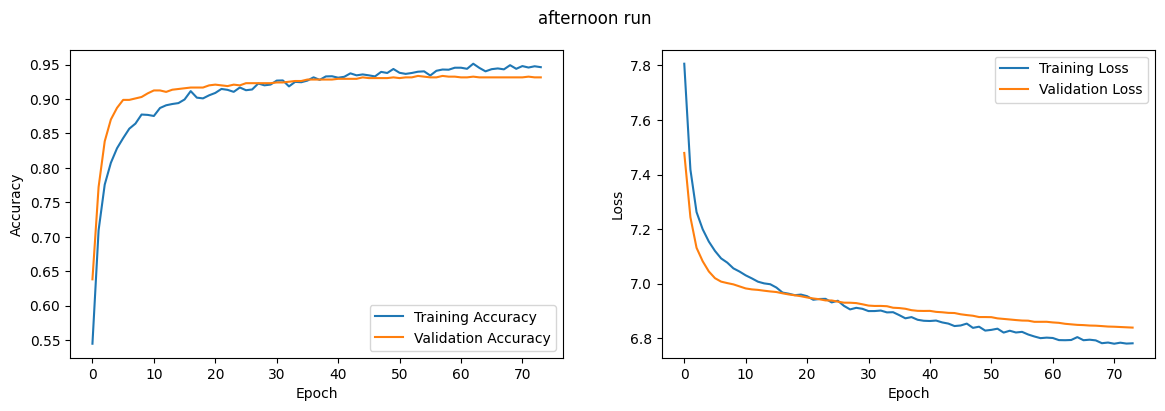

Best train_accuracy: 0.9513
Best train_loss: 6.7795
Best val_accuracy: 0.9335
Best val_loss: 6.8387
Last improvement at epoch: 54


In [18]:
plot_history(comment, history)

Found 4743 files belonging to 2 classes.
Using 3795 files for training.
Found 4743 files belonging to 2 classes.


2024-07-12 18:06:45.146488: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2024-07-12 18:06:45.638856: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-07-12 18:06:45.978270: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.

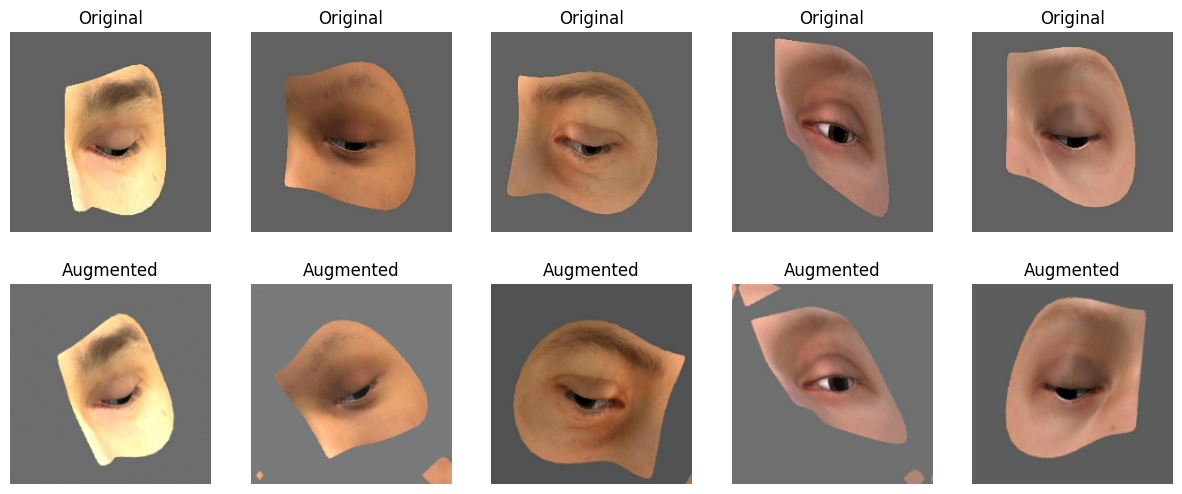

In [19]:
synth_train_data_augm = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2, skip_preprocessing=True)
synth_train_data_orig = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, skip_preprocessing=True)

plot_images(img_orig=synth_train_data_orig, img_augm=synth_train_data_augm)

Found 4743 files belonging to 2 classes.
Using 948 files for validation.


2024-07-12 18:06:46.376910: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step


2024-07-12 18:06:47.463200: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


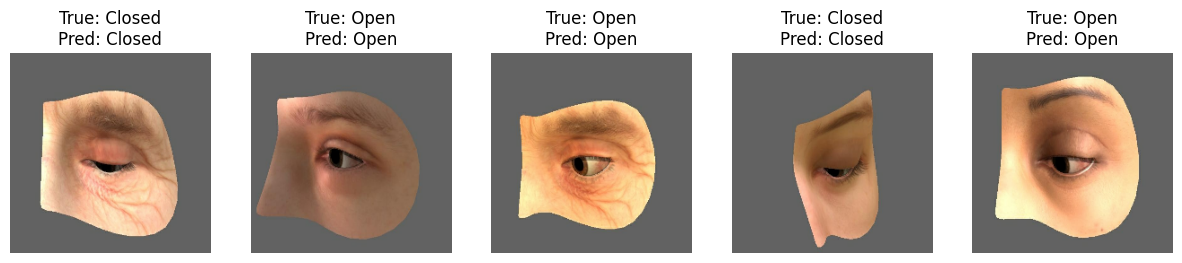

In [20]:
synth_valid_data_skip_preprocessing = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='validation', validation_split=0.2, skip_preprocessing=True)

plot_predictions(model=model, dataset=synth_valid_data, dataset_visual=synth_valid_data_skip_preprocessing)